In [6]:
import sklearn
from sklearn.ensemble import RandomForestClassifier as clf
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle

In [7]:
data = pd.read_csv('C:\\Users\\HP\\PycharmProjects\\JupyterProject1\\practice_file\\heart.csv')
data_X = data.drop(columns=['target'])
data_y = data['target']
trainX,testX,trainY,testY = train_test_split(data_X, data_y, test_size=0.3)
my_model = clf(n_estimators=310)
my_model.fit(trainX,trainY)
my_model.score(testX,testY)

0.8461538461538461

In [8]:
pickle.dump(my_model,open('my_model.pkl', 'wb'))

In [9]:
loaded_model = pickle.load(open('my_model.pkl', 'rb'))
loaded_model.score(testX,testY)


0.8461538461538461

In [10]:
import kagglehub as kagglehub
from kagglehub import KaggleDatasetAdapter
mobile_data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "iabhishekofficial/mobile-price-classification",
    "train.csv")


In [11]:
mobile_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [12]:
loaded_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 310,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [13]:
loaded_model = loaded_model.set_params(n_estimators=500)
loaded_model.fit(trainX,trainY)
loaded_model.score(testX,testY)

0.8241758241758241

In [14]:
pickle.dump(loaded_model,open('my_model.pkl', 'wb'))

In [15]:
new_modle = pickle.load(open('my_model.pkl', 'rb'))
new_modle.score(testX,testY)

0.8241758241758241

In [16]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [17]:
# age_g = input("Enter your age: ")
# sex_g = input("Enter your sex (0 for female, 1 for male): ")
# trestbps_g = input("Enter your resting blood pressure: ")
# chol_g = input("Enter your cholesterol level: ")
# fbs_g = input("Enter your fasting blood sugar (0 for false, 1 for true): ")
# restecg_g = input("Enter your resting electrocardiographic results (0, 1, or 2): ")
# cp_g = input("Enter your chest pain type (0, 1, 2, or 3): ")
# thalach_g = input("Enter your maximum heart rate achieved: ")
# exang_g = input("Enter your exercise-induced angina (0 for no, 1 for yes): ")
# oldpeak_g = input("Enter your ST depression induced by exercise relative to rest: ")
# slope_g = input("Enter the slope of the peak exercise ST segment (0, 1, or 2): ")
# ca_g = input("Enter the number of major vessels (0-3) colored by fluoroscopy: ")
# thal_g = input("Enter your thalassemia status (1 for normal, 2 for fixed defect, 3 for reversable defect): ")

In [18]:
# user_input = pd.DataFrame(
#     [[int(age_g), int(sex_g), int(cp_g), int(trestbps_g), int(chol_g),
#       int(fbs_g), int(restecg_g), int(thalach_g), int(exang_g),
#       float(oldpeak_g), int(slope_g), int(ca_g), int(thal_g)]],
#     columns=data_X.columns
# )
# result_g = new_modle.predict(user_input) #get data and predict target value
# if result_g[0] == 1:
#     print("You are at risk of heart disease.",new_modle.predict_proba(user_input)[0][1]*100,"%") # print the result and also gives probabilty of accurance
# else:
#     print("You are not at risk of heart disease.",new_modle.predict_proba(user_input)[0][0]*100,"%")


## Classification Model evaluation

In [19]:
## cross validation score
from sklearn.model_selection import cross_val_score
print(f"Random Forest Classifier CV: {[f'{s * 100:.2f}%' for s in cross_val_score(new_modle, data_X, data_y, cv=5)]}")

Random Forest Classifier CV: ['83.61%', '90.16%', '80.33%', '80.00%', '76.67%']


In [20]:
# Area Under the Curve (AUC) score
from sklearn.metrics import roc_auc_score
y_pred_proba = new_modle.predict_proba(testX)[:, 1] #Gets the probability predictions for each class on the test data and Selects only the probabilities for class 1 (the positive class - heart disease)
print("AUC score:", roc_auc_score(testY, y_pred_proba))

AUC score: 0.9117357001972386


# Ploting the ROC curve

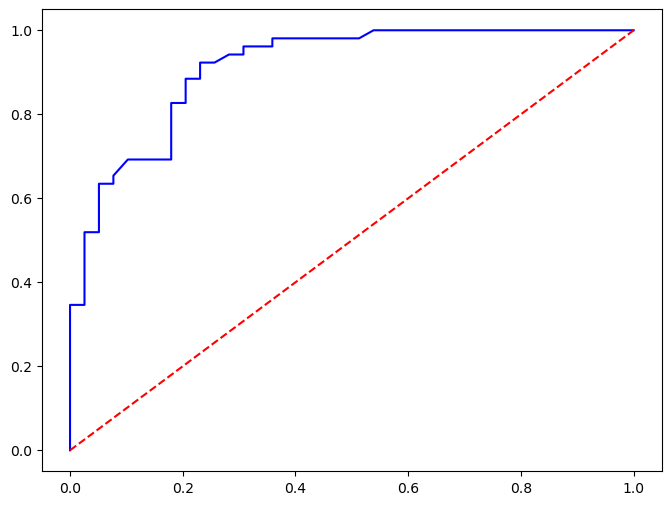

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve # roc curve is imported from sklern
fpr, tpr, thresholds = roc_curve(testY, y_pred_proba) # roc_curve function is used to calculate the false positive rate, true positive rate and thresholds for the ROC curve
plt.figure(figsize=(8, 6)) # make a figure
auc = roc_auc_score(testY, y_pred_proba)  # compute once, store it
# Plot the ROC curve: True Positive Rate (TPR) vs False Positive Rate (FPR)
# at every possible classification threshold. The label shows the AUC score,
# a single number (0 to 1) summarizing how well the model separates the classes.
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc:.2f})')

# Plot the diagonal reference line (0,0) to (1,1), representing a random-guess
# classifier. The closer our blue curve is to the top-left corner (away from
# this line), the better our model performs.
plt.plot([0, 1], [0, 1], color='red', linestyle='--');

# Ploting the confusion matrix
#### every quadrant of confusion matrix has a meaning i.e True Positive, True Negative, False Positive, False Negative
#### the first row of confusion matrix is for the actual class 0 and the second row is for the actual class 1. The first column is for the predicted class 0 and the second column is for the predicted class 1.
#### the first row and first column is for the True Negative, the first row and second column is for the False Positive, the second row and first column is for the False Negative, and the second row and second column is for the True Positive.


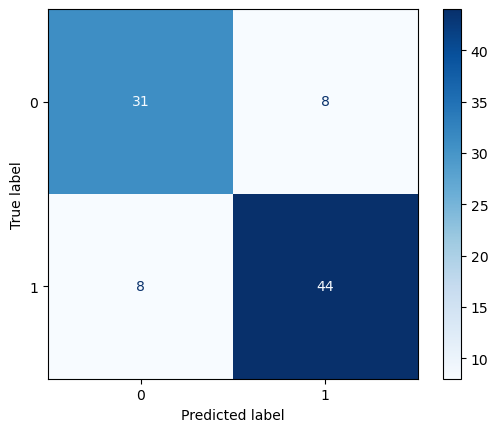

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # imported confusion matrix calculator and cunfusion matrix displayer
y_pred = new_modle.predict(testX) #taking predicted values
cm = confusion_matrix(testY, y_pred) # making confusion matrix and giving argument of testy and ypredicted
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=new_modle.classes_) # making a display of confusion matrix adn giving argument of cunfusion matrix and lables of models that are 0 and 1
disp.plot(cmap=plt.cm.Blues); #ploting and customizing the colour of confusion matrix

#### 4 Classificaton metrics are used to evaluate the performance of a classification model. These metrics are:
#### 1. Accuracy: The proportion of correctly predicted instances out of the total instances. It is calculated as (TP + TN) / (TP + TN + FP + FN), where TP is True Positives, TN is True Negatives, FP is False Positives, and FN is False Negatives.
#### 2. Precision: The proportion of correctly predicted positive instances out of the total predicted positive instances. It is calculated as TP / (TP + FP).
#### Recall asked: "Of everyone who's actually sick, how many did I catch?"
#### 3. Recall (Sensitivity or True Positive Rate): The proportion of correctly predicted positive instances out of the total actual positive instances. It is calculated as TP / (TP + FN).
#### Precision asks a completely different question: "Of everyone I told was sick, how many actually were?"
#### 4. F1 Score: The harmonic mean of precision and recall. It is calculated as 2 * (Precision * Recall) / (Precision + Recall). The F1 score is a better measure of the incorrectly classified cases than the Accuracy metric, especially when the class distribution is imbalanced.

In [23]:
from sklearn.metrics import classification_report # imported classification report to get the metrics of classification
print(classification_report(testY, y_pred)) # print the classification report and give argument of testy and ypredicted

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        39
           1       0.85      0.85      0.85        52

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



## Scoring metrics for classification models by using cross validation score

In [28]:
# Cross-validation works by testing your model multiple times on different slices of the data. The scoring parameter allows you to specify which metric to use for evaluation. Here are some common scoring metrics for classification models:
from sklearn.model_selection import cross_val_score
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in scoring_metrics:
    scores = cross_val_score(new_modle, data_X, data_y, cv=5, scoring=metric)
    print(f"{metric.capitalize()} CV: {[f'{s * 100:.2f}%' for s in scores]}")

Accuracy CV: ['83.61%', '90.16%', '78.69%', '76.67%', '76.67%']
Precision CV: ['82.86%', '93.55%', '83.87%', '79.41%', '74.36%']
Recall CV: ['90.91%', '87.88%', '81.82%', '81.82%', '84.85%']
F1 CV: ['85.29%', '90.62%', '83.08%', '84.06%', '81.69%']
Roc_auc CV: ['88.04%', '95.35%', '90.21%', '90.01%', '86.31%']
